In [1]:
import pandas as pd 
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [2]:
df = pd.read_csv(r'Churn_Modelling.csv')

In [3]:
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
5656,5657,15736769,Lucchesi,663,France,Female,27,9,0.00,2,1,0,150850.29,0
8593,8594,15722037,Alvarez,610,Germany,Male,36,7,115462.02,1,0,1,42581.04,0
1741,1742,15742638,Wang,747,France,Female,25,4,0.00,2,0,1,42039.67,0
2947,2948,15793813,Onochie,774,France,Male,36,7,103688.19,1,0,1,118971.74,0
4893,4894,15656263,Teng,764,Spain,Male,29,5,0.00,2,1,0,65868.28,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [5]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [6]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [7]:
df.drop(['RowNumber','CustomerId','Surname'],inplace= True,axis=1)

In [8]:
df.sample(2)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
8290,797,France,Male,37,4,75263.70,1,1,0,85801.77,0
6459,606,Germany,Male,45,5,63832.43,1,1,1,93707.80,0


In [9]:
df = pd.get_dummies(df,columns = ['Geography','Gender'],drop_first= True)

In [10]:
from sklearn.model_selection import train_test_split
X = df.drop(columns = ['Exited'])
y = df['Exited']


In [11]:
x_tr,x_tst,y_tr,y_tst = train_test_split(X,y,test_size=0.1,random_state=42)

In [12]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [13]:
x_tr_sc = sc.fit_transform(x_tr)
x_tst_sc = sc.transform(x_tst)

In [75]:
model =Sequential()

model.add(Dense(11,activation= 'sigmoid',input_dim = 11))
model.add(Dense(11,activation = 'sigmoid'))
model.add(Dense(1,activation= 'sigmoid'))

c:\Users\Krish\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [76]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
model.compile(loss = 'binary_crossentropy',optimizer='Adam',metrics=['accuracy','precision'])
history = model.fit(x_tr_sc,y_tr,epochs = 100,validation_split=0.1)

Epoch 1/100


254/254 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8632 - loss: 0.3290 - precision: 0.7514 - val_accuracy: 0.8478 - val_loss: 0.3410 - val_precision: 0.6972
Epoch 2/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8641 - loss: 0.3287 - precision: 0.7575 - val_accuracy: 0.8489 - val_loss: 0.3415 - val_precision: 0.6864
Epoch 3/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8641 - loss: 0.3287 - precision: 0.7543 - val_accuracy: 0.8467 - val_loss: 0.3401 - val_precision: 0.6750
Epoch 4/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8659 - loss: 0.3287 - precision: 0.7656 - val_accuracy: 0.8478 - val_loss: 0.3414 - val_precision: 0.6593
Epoch 5/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8647 - loss: 0.3286 - precision: 0.7540 - val_accuracy: 0.8533 - val_loss: 0.3411 - val_precision: 0.6905
Epoch 6/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8668 - loss: 0.3284 - precision: 0.7715 - val_accuracy: 0.8478 - val_loss: 0.346

In [90]:
y_pred_prob = model.predict(x_tst_sc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [91]:
from sklearn.metrics import roc_curve
fpr,tpr,thresholds = roc_curve(y_tst,y_pred_prob)

In [92]:
import plotly.graph_objects as go
import numpy as np

trace0 = go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines',
    name='ROC Curve'
)

n = 10
indices = np.arange(len(thresholds)) % n == 0

trace1 = go.Scatter(
    x=fpr[indices],
    y=tpr[indices],
    mode='markers',
    name='Threshold Points'
)

trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

layout = go.Layout(
    title='ROC Curve',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=True
)

fig = go.Figure(data=data, layout=layout)

fig.show()

In [93]:
optimal_idx  = np.argmax(tpr-fpr)
optimal_thershold = thresholds[optimal_idx]
print("Optimal thershold is : ",optimal_thershold)

Optimal thershold is :  0.2496754676103592


In [95]:
y_pred = np.where(y_pred_prob >  0.24 ,1,0)

In [96]:
from sklearn.metrics import accuracy_score,confusion_matrix
accuracy_score(y_tst,y_pred)

0.812

In [97]:
confusion_matrix(y_tst,y_pred)

array([[676, 133],
       [ 55, 136]])

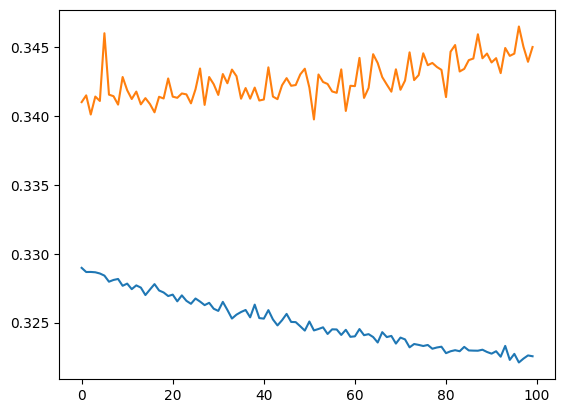

In [103]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

(1000, 1)